# **DECISION TREE**

In [4]:
## commonly used libraries in decision tree
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, r2_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

**Decision tree for classification**

**IRIS Dataset**

In [17]:
from sklearn.datasets import load_iris

iris = load_iris()
print(iris.DESCR)  # Prints full description, background, and feature details

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [28]:
# Loads features and target combined into a Pandas DataFrame
iris_df = load_iris(as_frame=True).frame
iris_df.head()  # View the first 5 rows
print(iris_df['target'].unique()) # Output: array([0, 1, 2])
print(iris_df['target'].nunique()) # Output: 3
print(iris_df['target'].value_counts())
iris_df.sample(5)  # Returns 5 randomly selected rows

[0 1 2]
3
target
0    50
1    50
2    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
126,6.2,2.8,4.8,1.8,2
78,6.0,2.9,4.5,1.5,1
85,6.0,3.4,4.5,1.6,1
120,6.9,3.2,5.7,2.3,2
95,5.7,3.0,4.2,1.2,1


When you load a dataset as a DataFrame using 
load_iris(as_frame=True).frame, it encodes the target values as numeric IDs (0, 1, 2) rather than string names to make them directly usable for mathematical model training.

The mapping between these numeric IDs and the actual class names is stored separately in the dataset object's target_names attribute:

- 0 $\rightarrow$ 'setosa'

- 1 $\rightarrow$ 'versicolor'

- 2 $\rightarrow$ 'virginica'

In [29]:
from sklearn.datasets import load_iris

#How to view the target names alongside numbers
#Check the mapping list:

iris = load_iris()
print(iris.target_names)
# Output: ['setosa' 'versicolor' 'virginica']

['setosa' 'versicolor' 'virginica']


In [30]:
#Add the human-readable text column back into your DataFrame:
#If you want the text label displayed next to the numbers in your DataFrame, you can map target_names to the numeric target column

iris = load_iris()
df = load_iris(as_frame=True).frame

# Create a new column by mapping numbers to string names
df['species'] = df['target'].map(lambda x: iris.target_names[x])

df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
12,4.8,3.0,1.4,0.1,0,setosa
65,6.7,3.1,4.4,1.4,1,versicolor
52,6.9,3.1,4.9,1.5,1,versicolor
142,5.8,2.7,5.1,1.9,2,virginica
46,5.1,3.8,1.6,0.2,0,setosa


In [5]:
#Load the diabetes dataset

iris = datasets.load_iris()
iris_X, iris_y = iris.data, iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print(f"Size of the dataset: {iris_X.shape}")
print(f"No. features: {len(feature_names)}")
print(f"Features' names: {feature_names}")
print(f"No. class names: {len(target_names)}")
print(f"Class names: {target_names}")

Size of the dataset: (150, 4)
No. features: 4
Features' names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
No. class names: 3
Class names: ['setosa' 'versicolor' 'virginica']


Scikit-learn does not know automatically for custom or arbitrary datasets. 

It only knows for its built-in toy datasets (like Iris, Wine, Digits, or California Housing) because the library authors pre-packaged those specific files with explicit .data and .target keys.

In [6]:
iris_df = pd.DataFrame(iris_X, columns=feature_names)
iris_df['target'] = iris_y
iris_df['species'] = [target_names[i] for i in iris_y]
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


The author of that snippet knew to write lines 2 and 3 specifically because they inspected iris_y and target_names beforehand:

- Line 1 (columns=feature_names): They knew iris_X was just a raw 2D NumPy matrix of numbers, so they supplied column names stored in feature_names.

- Line 2 (iris_df['target'] = iris_y): They knew iris_y contained array numbers [0, 1, 2] representing class categories.

- Line 3 ([target_names[i] for i in iris_y]): They saw iris_y had numbers 0, 1, and 2, and target_names was a list where index 0 was 'setosa', index 1 was 'versicolor', and index 2 was 'virginica'. The list comprehension maps those numeric IDs directly to human-readable names.

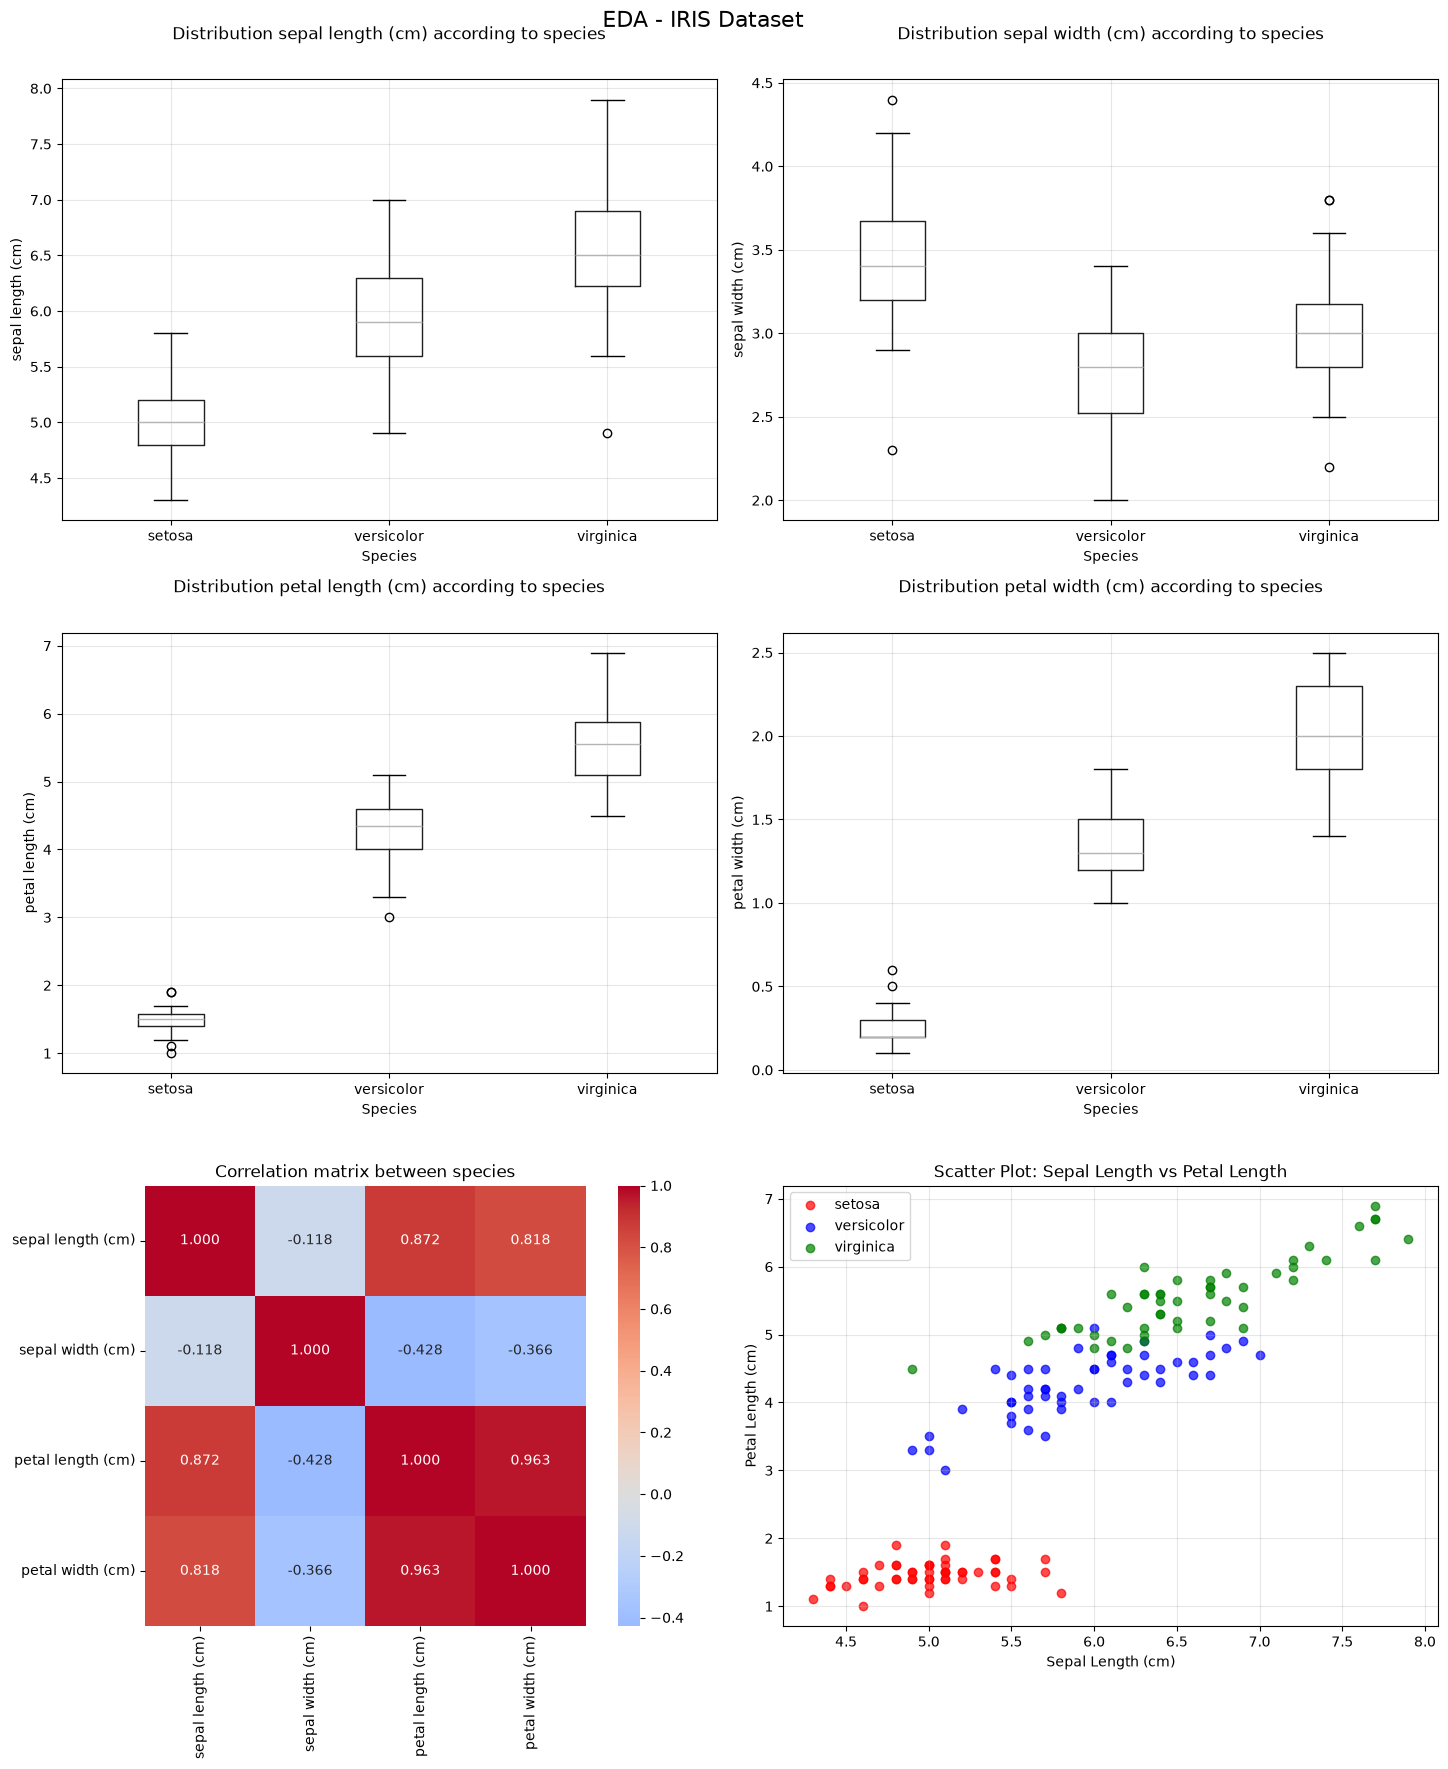

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(15,18))

# 1. Distribution of characteristics by species

for i, feature in enumerate(feature_names):
    ax = axes[i//2, i%2]
    iris_df.boxplot(column=feature, by="species", ax = ax)
    ax.set_title(f"Distribution {feature} according to species", fontsize=12, pad=29)
    ax.set_xlabel("Species", fontsize = 10)
    ax.set_ylabel(feature, fontsize = 10)
    ax.grid(True, alpha = 0.3)

## 2. Correlation matrix
axes[2,0].remove()
axes[2,0] = plt.subplot(3, 2, 5)
correlation_matrix = iris_df[feature_names].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0,
            square=True, ax=axes[2, 0], fmt=".3f")
axes[2,0].set_title("Correlation matrix between species", fontsize = 12)

## 3. Scatter plot
axes[2,1].remove()
axes[2,1] = plt.subplot(3,2,6)
colors = ["red", "blue", "green"]

for i, species in enumerate(target_names):
    species_data = iris_df[iris_df["species"] == species]
    axes[2,1].scatter(species_data["sepal length (cm)"],
                      species_data["petal length (cm)"],
                      label = species, alpha=0.7,
                      color = colors[i])

axes[2,1].set_xlabel("Sepal Length (cm)", fontsize = 10)
axes[2,1].set_ylabel("Petal Length (cm)", fontsize = 10)
axes[2,1].set_title("Scatter Plot: Sepal Length vs Petal Length", fontsize = 12)
axes[2,1].legend()
axes[2,1].grid(True, alpha = 0.3)

plt.suptitle("EDA - IRIS Dataset", fontsize=16, y = 0.98)
plt.tight_layout()
plt.savefig("01_EDA_IRIS.png", dpi=600, bbox_inches="tight")
plt.show()

In [11]:
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    iris_X,
    iris_y,
    test_size=0.2,
    random_state=42,
    stratify=iris_y
)

print(f"Size of training set: {X_train_iris.shape}")
print(f"Size of testing set: {X_test_iris.shape}")
print(f"Distribution in training set: {np.bincount(y_train_iris)}")
print(f"Distribution in testing set: {np.bincount(y_test_iris)}")

Size of training set: (120, 4)
Size of testing set: (30, 4)
Distribution in training set: [40 40 40]
Distribution in testing set: [10 10 10]


In [12]:
#StandardScaler application

scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)

X_test_iris_scaled = scaler_iris.transform(X_test_iris)

In [14]:
#Build the decision tree model

dt_classifier = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dt_classifier.fit(X_train_iris,y_train_iris)

#predict
y_pred_iris = dt_classifier.predict(X_test_iris)

#Evaluation
accuracy = accuracy_score(y_test_iris, y_pred_iris)
print(f"Accuracy score: {accuracy:.4f}")

Accuracy score: 0.9667


In [15]:
print(classification_report(y_test_iris, y_pred_iris,
                            target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



[Text(0.375, 0.875, 'Petal_Length <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 40, 40]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'Petal_Width <= 1.65\ngini = 0.5\nsamples = 80\nvalue = [0, 40, 40]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'Petal_Length <= 4.95\ngini = 0.133\nsamples = 42\nvalue = [0, 39, 3]'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 38\nvalue = [0, 38, 0]'),
 Text(0.375, 0.125, 'gini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.75, 0.375, 'Petal_Length <= 4.85\ngini = 0.051\nsamples = 38\nvalue = [0, 1, 37]'),
 Text(0.625, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 35\nvalue = [0, 0, 35]')]

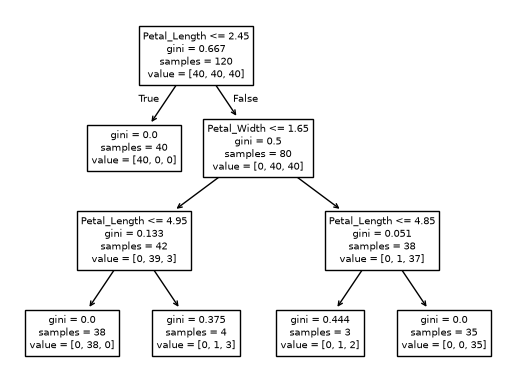

In [16]:
from sklearn.tree import plot_tree

#visualisation
plot_tree(dt_classifier, feature_names=[
    "Senpal_Length", "Senpal_Width",
    "Petal_Length", "Petal_Width"
])